In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import numpy as np
import pandas as pd
import scvi
from pathlib import Path

/local/fkriegel/miniconda3/envs/scvi_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path_adata = "/share/runs/2026/03-26_moma_pd_jbecher/stage5/pd_snrna_gen/pd_snrna_gen_filtered.h5ad"
adata = sc.read_h5ad(path_adata)

In [3]:
a = adata.X[0].toarray()
a[a>0]

array([ 1,  1, 11, ...,  1,  2,  8], shape=(11342,))

In [4]:
# load RNA and extract PMI
path_bulk = "/share/runs/2026/03-26_moma_pd_jbecher/stage4/pd_bulk_gen/pd_bulk_gen_harmonized.h5ad"
bulk = sc.read_h5ad(path_bulk)
pmi = bulk.obs['PMI']
sample_id_bulk = bulk.obs['sample_id'].values

# correlate pmi
res = adata.obs.groupby("gen_bulk_rna_id")["total_counts"].median()
len(res)

/tmp/ipykernel_4098156/1677739015.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  res = adata.obs.groupby("gen_bulk_rna_id")["total_counts"].median()


45

In [5]:
type(res.drop('').to_frame())

pandas.core.frame.DataFrame

In [6]:
res.drop('').to_frame()

,total_counts
gen_bulk_rna_id,
SL450742,3992.0
SL450744,5073.0
SL450747,19355.0
SL450752,6931.0
SL450756,5185.0
SL450757,6579.5
SL450764,1454.0
SL450804,3191.0
SL452595,7490.0


In [7]:
pmi.to_frame().drop("SL453056")

,PMI
obs_id,
SL453305,30
SL452879,48
SL450742,33
SL452595,48
SL453901,24
SL450744,24
SL453905,7.5
SL452597,7.3
SL452602,42


In [ ]:
# check if PMI correlates with total counts. The correlation in negelectable
res.drop('').drop("SL453056").to_frame().merge(pmi.to_frame().drop("SL453056"), how='left', left_index=True , right_index=True).corr()

,total_counts,PMI
total_counts,1.00000,-0.13294
PMI,-0.13294,1.00000


In [9]:
adata.obs["called_doublet_scrublet"].sum()

np.int64(0)

According to the paper, the different donors were run in one seqeuncing.

In [10]:
adata.obs.groupby("sample_id").apply(
    lambda d: (
        (d.total_counts >= adata.obs.total_counts.quantile(0.9)) |
        (d.n_genes_by_counts >= adata.obs.n_genes_by_counts.quantile(0.9))
    ).mean()
)

/tmp/ipykernel_4098156/2890339992.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby("sample_id").apply(
/tmp/ipykernel_4098156/2890339992.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  adata.obs.groupby("sample_id").apply(


sample_id
PFCTX001    0.143526
PFCTX002    0.083323
PFCTX003    0.122688
PFCTX004    0.467520
PFCTX005    0.098448
PFCTX006    0.585308
PFCTX007    0.469423
PFCTX008    0.115062
PFCTX009    0.133043
PFCTX010    0.181440
PFCTX011    0.103550
PFCTX012    0.110034
PFCTX013    0.187208
PFCTX014    0.116259
PFCTX015    0.181244
PFCTX016    0.376222
PFCTX017    0.154382
PFCTX018    0.113927
PFCTX019    0.141871
PFCTX020    0.017255
PFCTX021    0.122704
PFCTX022    0.143299
PFCTX023    0.075919
PFCTX024    0.155775
PFCTX025    0.034503
PFCTX026    0.047101
PFCTX027    0.058894
PFCTX028    0.169523
PFCTX029    0.123019
PFCTX030    0.102844
PFCTX031    0.132744
PFCTX032    0.084204
PFCTX033    0.067368
PFCTX034    0.092347
PFCTX035    0.138125
PFCTX036    0.205761
PFCTX037    0.078141
PFCTX038    0.231624
PFCTX039    0.033996
PFCTX040    0.049140
PFCTX041    0.016622
PFCTX042    0.176471
PFCTX043    0.191213
PFCTX044    0.079118
PFCTX045    0.064250
PFCTX046    0.016538
dtype: float64

In [11]:
import numpy as np
n_cells = adata.obs.groupby("sample_id").size()
med_counts = adata.obs.groupby("sample_id").total_counts.median()
print(np.corrcoef(n_cells, med_counts)[0,1])

-0.5331270362704766


/tmp/ipykernel_4098156/488850428.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  n_cells = adata.obs.groupby("sample_id").size()
/tmp/ipykernel_4098156/488850428.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  med_counts = adata.obs.groupby("sample_id").total_counts.median()


Corrleation between n_cells and median counts is significantly negative: the less cells, the more total counts. So the deep samples aren't deep because of multiplets; they're deep because less material went into the lane.

In [13]:
#!/usr/bin/env python
"""
Per-sample doublet detection for the Nido PFCTX snRNA-seq dataset.

Order of operations:
  1. lower QC filters (global; floors on what counts as a usable nucleus)
  2. per-sample scrublet with self-selected threshold
  3. diagnostics: threshold spread, call rate vs depth, depth before/after

No upper count/gene filter is applied here. The depth-spread question is
answered by the diagnostic at the end, not assumed up front.
"""

import numpy as np
import pandas as pd
import scanpy as sc
import scrublet as scr
from pathlib import Path

# ---------------------------------------------------------------- config

IN_PATH   = Path("PATH/TO/your.h5ad")          # <-- set this
OUT_PATH  = Path("/local/fkriegel/Moma_PD_scSAE/dat/nido_doublets.h5ad")
SAMPLE_KEY = "sample_id"

MIN_GENES   = 500     # their min.features
MIN_COUNTS  = 1000    # their nCount_RNA > 1000
MAX_PCT_MT  = 3.0
MAX_PCT_RB  = 2.0

EXPECTED_DOUBLET_RATE = 0.05   # prior only; threshold is data-driven
RANDOM_SEED = 0

sc.settings.n_jobs = 8

# ------------------------------------------------------------------ load

adata.var_names_make_unique()

# CellBender output is already background-corrected counts.
# Make sure .X is counts, not something normalised upstream.
assert np.allclose(adata.X[:50].data % 1, 0), ".X does not look like integer counts"

adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["rb"] = adata.var_names.str.match(r"^RP[SL]")

sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "rb"], percent_top=None, log1p=False, inplace=True
)

# ------------------------------------------------------- lower QC filters

n0 = adata.n_obs
keep = (
    (adata.obs.n_genes_by_counts >= MIN_GENES)
    & (adata.obs.total_counts > MIN_COUNTS)
    & (adata.obs.pct_counts_mt < MAX_PCT_MT)
    & (adata.obs.pct_counts_rb < MAX_PCT_RB)
)
adata = adata[keep].copy()
print(f"lower QC: {n0} -> {adata.n_obs} ({adata.n_obs / n0:.1%} kept)")

# per-sample retention through the lower filters, for the PMI check later
retention = (
    pd.DataFrame({SAMPLE_KEY: pd.Categorical(adata.obs[SAMPLE_KEY])})
    .value_counts().rename("n_post").to_frame()
)

# ------------------------------------------------------ per-sample scrublet

scores = pd.Series(index=adata.obs_names, dtype=float)
calls  = pd.Series(index=adata.obs_names, dtype=object)
diag   = []

for sid, idx in adata.obs.groupby(SAMPLE_KEY, observed=True).groups.items():
    sub = adata[idx]
    n = sub.n_obs
    if n < 100:
        print(f"{sid}: only {n} cells, skipping scrublet")
        scores[idx] = np.nan
        calls[idx] = "unknown"
        continue

    s = scr.Scrublet(
        sub.X,
        expected_doublet_rate=EXPECTED_DOUBLET_RATE,
        random_state=RANDOM_SEED,
    )
    doublet_scores, predicted = s.scrub_doublets(
        min_counts=2, min_cells=3,
        min_gene_variability_pctl=85, n_prin_comps=30,
        verbose=False,
    )

    auto_thresh = s.threshold_ if hasattr(s, "threshold_") else np.nan
    if predicted is None or np.isnan(auto_thresh):
        # scrublet failed to find a bimodal split; fall back to the prior
        # rather than silently calling nothing.
        auto_thresh = np.quantile(doublet_scores, 1 - EXPECTED_DOUBLET_RATE)
        predicted = doublet_scores > auto_thresh
        fallback = True
    else:
        fallback = False

    scores[idx] = doublet_scores
    calls[idx] = np.where(predicted, "doublet", "singlet")

    diag.append({
        SAMPLE_KEY: sid,
        "n_cells": n,
        "threshold": auto_thresh,
        "fallback": fallback,
        "call_rate": float(np.mean(predicted)),
        "median_score": float(np.median(doublet_scores)),
        "median_counts": float(np.median(sub.obs.total_counts)),
    })
    print(f"{sid}: n={n}, thresh={auto_thresh:.3f}, "
          f"called={np.mean(predicted):.1%}{' [FALLBACK]' if fallback else ''}")

adata.obs["scrublet_score"] = scores
adata.obs["scrublet_call"] = pd.Categorical(
    calls, categories=["singlet", "doublet", "unknown"]
)

diag = pd.DataFrame(diag).set_index(SAMPLE_KEY)

# ------------------------------------------------------------ diagnostics

print("\n=== per-sample thresholds ===")
print(diag[["n_cells", "threshold", "call_rate", "fallback"]].to_string())

print("\nthreshold spread: "
      f"median={diag.threshold.median():.3f}, "
      f"min={diag.threshold.min():.3f}, max={diag.threshold.max():.3f}")
if diag.fallback.any():
    print(f"!! {diag.fallback.sum()} sample(s) fell back to the fixed-rate "
          "threshold -- inspect their score histograms before trusting them.")

# A threshold far from the pack flags a sample whose score distribution
# is not bimodal, i.e. a bad sample rather than a rescuable one.
z = (diag.threshold - diag.threshold.median()) / diag.threshold.std()
if (z.abs() > 3).any():
    print("!! threshold outlier sample(s):", list(diag.index[z.abs() > 3]))

# Does the doublet call rate track sequencing depth? If it does, the deep
# samples are deep partly because of multiplets. If it does not, depth is
# a library-size effect and no upper filter is warranted.
r = np.corrcoef(diag.median_counts, diag.call_rate)[0, 1]
print(f"\ncorr(median total_counts, doublet call rate) = {r:.3f}")

# The actual test: does removing doublets collapse the depth spread?
before = adata.obs.groupby(SAMPLE_KEY, observed=True).total_counts.median()
after = (
    adata.obs[adata.obs.scrublet_call == "singlet"]
    .groupby(SAMPLE_KEY, observed=True).total_counts.median()
)
print("\ndepth spread (max/min of per-sample median total_counts)")
print(f"  before doublet removal: {before.max() / before.min():.2f}x")
print(f"  after doublet removal:  {after.max() / after.min():.2f}x")
print("  -> if roughly unchanged, the spread is library depth; keep all "
      "singlets and let normalisation handle it.")

# ----------------------------------------------------------------- write

diag.to_csv("doublet_diagnostics.csv")
adata.write_h5ad(OUT_PATH)
print(f"\nwrote {OUT_PATH} ({adata.n_obs} cells, doublets flagged not removed)")

lower QC: 365153 -> 365153 (100.0% kept)
PFCTX001: n=6126, thresh=0.534, called=0.1%
PFCTX002: n=6280, thresh=0.209, called=3.8%
PFCTX003: n=6187, thresh=0.419, called=0.3%
PFCTX004: n=3149, thresh=0.377, called=0.0%
PFCTX005: n=8400, thresh=0.391, called=0.0%
PFCTX006: n=1259, thresh=0.372, called=0.2%
PFCTX007: n=3351, thresh=0.488, called=0.2%
PFCTX008: n=6159, thresh=0.194, called=4.4%
PFCTX009: n=9508, thresh=0.397, called=0.1%
PFCTX010: n=8457, thresh=0.469, called=0.1%
PFCTX011: n=10062, thresh=0.333, called=0.6%
PFCTX012: n=10956, thresh=0.389, called=0.1%
PFCTX013: n=8986, thresh=0.587, called=0.1%
PFCTX014: n=6867, thresh=0.448, called=0.1%
PFCTX015: n=6790, thresh=0.573, called=0.0%
PFCTX016: n=3170, thresh=0.483, called=0.2%
PFCTX017: n=6566, thresh=0.302, called=0.7%
PFCTX018: n=7597, thresh=0.400, called=0.2%
PFCTX019: n=6848, thresh=0.543, called=0.1%
PFCTX020: n=1206, thresh=0.355, called=0.0%
PFCTX021: n=9460, thresh=0.515, called=0.1%
PFCTX022: n=7297, thresh=0.564, c

In [ ]:
#a = sc.read_h5ad("nido_doublets.h5ad")
d = adata.X.toarray()


AttributeError: 'numpy.ndarray' object has no attribute 'obs'

In [23]:
print(d.max(), np.mod(d, 1).max(), (adata.obs.total_counts.median()))

11814 0 6907.0


In [24]:
#!/usr/bin/env python
"""
Nido PFCTX: scVI integration + Leiden clustering.

Replaces Seurat RPCA anchor integration. Only job is producing trustworthy
cell type labels -- the latent space is not used downstream.

Doublet removal happens at the CLUSTER level here (their second pass), not
from the per-cell scrublet calls, which failed to threshold on 42/46 samples.
"""


OUT_PATH   = Path("/local/fkriegel/Moma_PD_scSAE/dat/nido_clustered.h5ad")
SAMPLE_KEY = "sample_id"
N_HVG      = 2000          # matches SelectIntegrationFeatures default
DOUBLET_RATE = 0.05
SEED = 0

scvi.settings.seed = SEED
scvi.settings.dl_num_workers = 4   # raise if GPU utilisation sits low
sc.settings.n_jobs = 8


# ------------------------------------------- doublet flag at a fixed rate
# Automatic thresholding failed on most samples, so use a stated prior
# instead of a broken fit. Flag only -- cells are not removed here.
adata.obs["doublet_flag"] = (
    adata.obs.groupby(SAMPLE_KEY, observed=True)
    .scrublet_score.rank(pct=True) > (1 - DOUBLET_RATE)
)
print(f"flagged {adata.obs.doublet_flag.sum()} cells "
      f"({adata.obs.doublet_flag.mean():.1%})")

# ------------------------------------------------------------------ HVGs
adata.layers["counts"] = adata.X.copy()

sc.pp.highly_variable_genes(
    adata, n_top_genes=N_HVG, flavor="seurat_v3",
    layer="counts", batch_key=SAMPLE_KEY, subset=False,
)

# Markers must survive HVG selection or the annotation step is blind.
MARKERS = {
    "ex":               ["SATB2", "SLC17A7"],
    "in":               ["GAD1", "SLC6A1"],
    "oligodendrocytes": ["MOG", "MOBP"],
    "astrocytes":       ["GFAP", "AQP4"],
    "microglia":        ["CSF1R", "CSF3R"],
    "endothelial":      ["CLDN5", "SLC2A1"],
    "OPC":              ["VCAN", "OLIG1"],
}
all_markers = [g for v in MARKERS.values() for g in v]
missing = [g for g in all_markers if g not in adata.var_names]
if missing:
    print(f"!! markers absent from the object: {missing}")
adata.var.loc[adata.var_names.isin(all_markers), "highly_variable"] = True

# ------------------------------------------------------------------ scVI
train = adata[:, adata.var.highly_variable].copy()

scvi.model.SCVI.setup_anndata(
    train, layer="counts", batch_key=SAMPLE_KEY,
    continuous_covariate_keys=["pct_counts_mt"],
)
model = scvi.model.SCVI(train, n_latent=30, n_layers=2)
model.train(early_stopping=True, accelerator="gpu", devices=[1])
model.save("scvi_model", overwrite=True)

adata.obsm["X_scVI"] = model.get_latent_representation()

# ------------------------------------------------------------ clustering
sc.pp.neighbors(adata, use_rep="X_scVI", n_neighbors=15)
sc.tl.umap(adata)

for res in (0.1, 0.5):
    sc.tl.leiden(adata, resolution=res, key_added=f"leiden_{res}",
                 flavor="igraph", n_iterations=2, directed=False)
    n = adata.obs[f"leiden_{res}"].nunique()
    print(f"leiden res={res}: {n} clusters")

# ------------------------------------------------- normalised expression
adata.X = adata.layers["counts"].copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.layers["lognorm"] = adata.X.copy()

# ----------------------------------------------------------- diagnostics
KEY = "leiden_0.5"

expr = sc.get.obs_df(adata, keys=all_markers + [KEY])
marker_mean = expr.groupby(KEY, observed=True).mean()

qc = adata.obs.groupby(KEY, observed=True).agg(
    n_cells=("total_counts", "size"),
    med_counts=("total_counts", "median"),
    med_genes=("n_genes_by_counts", "median"),
    pct_mt=("pct_counts_mt", "median"),
    doublet_frac=("doublet_flag", "mean"),
    n_samples=(SAMPLE_KEY, "nunique"),
    top_sample_frac=(SAMPLE_KEY,
                     lambda s: s.value_counts(normalize=True).iloc[0]),
)

report = qc.join(marker_mean.round(2))
print("\n=== per-cluster diagnostics ===")
print(report.to_string())

# Flags, not decisions -- inspect before acting on any of these.
print("\n--- candidates for removal ---")
for cl, row in report.iterrows():
    reasons = []
    if row.doublet_frac > 2 * DOUBLET_RATE:
        reasons.append(f"doublet-enriched ({row.doublet_frac:.1%})")
    if row.top_sample_frac > 0.5:
        reasons.append(f"sample-dominated ({row.top_sample_frac:.0%})")
    # a cluster expressing markers of >2 lineages is likely doublets
    lineages = sum(
        marker_mean.loc[cl, genes].mean() > marker_mean[genes].mean().mean()
        for genes in MARKERS.values()
    )
    if lineages > 2:
        reasons.append(f"{lineages} lineages co-expressed")
    if row.med_genes < 800:
        reasons.append(f"low complexity (med {row.med_genes:.0f} genes)")
    if reasons:
        print(f"  cluster {cl}: " + "; ".join(reasons))

report.to_csv("cluster_diagnostics.csv")
adata.write_h5ad(OUT_PATH)
print(f"\nwrote {OUT_PATH}")

# Next: inspect, assign cell types, drop flagged clusters, then apply the
# marker-pair trim (nonzero counts for both markers of the assigned type).
# Check that trim's retention per sample -- it is depth-dependent and your
# samples span a 27x depth range.

Seed set to 0


flagged 18119 cells (5.0%)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA B200') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]
/local/fkriegel/miniconda3/envs/scvi_env/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Epoch 22/22: 100%|██████████| 22/22 [20:49<00:00, 56.85s/it, v_num=1, train_loss=884]

`Trainer.fit` stopped: `max_epochs=22` reached.


Epoch 22/22: 100%|██████████| 22/22 [20:49<00:00, 56.78s/it, v_num=1, train_loss=884]
leiden res=0.1: 17 clusters
leiden res=0.5: 30 clusters

=== per-cluster diagnostics ===
            n_cells  med_counts  med_genes    pct_mt  doublet_frac  n_samples  top_sample_frac  SATB2  SLC17A7  GAD1  SLC6A1   MOG  MOBP  GFAP  AQP4  CSF1R  CSF3R  CLDN5  SLC2A1  VCAN  OLIG1
leiden_0.5                                                                                                                                                                                    
0             25492     13330.0     4697.0  0.420230      0.054409         46         0.063785   1.31     0.48  0.01    0.01  0.01  0.07  0.01  0.02   0.00   0.00   0.00    0.03  0.01   0.00
1              4006     12059.5     4495.0  0.333294      0.038442         45         0.064403   1.34     0.46  0.01    0.01  0.01  0.12  0.01  0.03   0.00   0.00   0.00    0.03  0.00   0.00
2             12877     10790.0     4412.0  0.196618      0.4

As in the paper, in this first coarse clusteriing run, we identify clusters with high doublet fraction and remove them.

In [49]:
clu_doublet = ['2', '13', '17', '22', '27', '28', '29']
adata.obs['leiden_0.5']
print(f"before doublet filtering: {len(adata)}")
adata = adata[~adata.obs['leiden_0.5'].isin(clu_doublet)]
print(f"before doublet filtering: {len(adata)}")

before doublet filtering: 365153
before doublet filtering: 335090


In [56]:
#!/usr/bin/env python
"""
Nido PFCTX: cell type assignment, junk cluster removal, marker-pair trim.

Runs on the existing leiden_0.5 labels -- no re-clustering. The latent space
is not recomputed, so cluster IDs stay stable relative to nido_clustered.h5ad.

Cluster IDs have already shifted between runs, so the manual assignment is
checked against a marker-based score before it is applied. If they disagree,
the script stops rather than mislabelling silently.
"""

import numpy as np
import pandas as pd
import scanpy as sc
from pathlib import Path

IN_PATH  = Path("/local/fkriegel/Moma_PD_scSAE/dat/nido_clustered.h5ad")
OUT_PATH = Path("/local/fkriegel/Moma_PD_scSAE/dat/nido_annotated.h5ad")
KEY = "leiden_0.5"
SAMPLE_KEY = "sample_id"

# Their code is rowSums(both markers) > 0, i.e. AT LEAST ONE nonzero, despite
# the methods text reading as "both". "any" reproduces their 11% attrition;
# "both" would be far harsher here because SLC17A7 is weakly recovered.
TRIM_MODE = "any"          # "any" | "both"

# The q90 count/gene ceiling. Off by default: it is a poor multiplet proxy and
# with a 27x depth range it removes cells unevenly across donors, pushing a
# technical gradient into cell-type proportions. Set True to match their Fig 1.
APPLY_Q90 = False

MARKERS = {
    "ex":               ["SATB2", "SLC17A7"],
    "in":               ["GAD1", "SLC6A1"],
    "oligodendrocytes": ["MOG", "MOBP"],
    "astrocytes":       ["GFAP", "AQP4"],
    "microglia":        ["CSF1R", "CSF3R"],
    "endothelial":      ["CLDN5", "SLC2A1"],
    "OPC":              ["VCAN", "OLIG1"],
}
all_markers = [g for v in MARKERS.values() for g in v]

# Manual assignment, from the diagnostics table. Keyed to the CURRENT run.
ASSIGN = {
    "0": "ex", "1": "ex", "4": "ex", "6": "ex", "7": "ex", "8": "ex",
    "9": "ex", "10": "ex", "21": "ex", "23": "ex", "24": "ex",
    "11": "in", "12": "in", "14": "in", "19": "in", "20": "in",
    "25": "in", "26": "in",
    "15": "oligodendrocytes",
    "3":  "astrocytes",
    "18": "OPC",
    "16": "microglia",
    "5":  "endothelial",
}

REMOVE = {
    "2":  "heterotypic doublets (40% flagged, 5 lineages)",
    "17": "heterotypic doublets (35% flagged, oligo+astro)",
    "22": "homotypic ex-ex doublets (deepest cluster, 20% flagged)",
    "27": "ambient (952 median genes, 81% one sample)",
    "13": "low complexity, sample-dominated (77%)",
    "28": "oligo-like but 74% one sample, 15 samples, pct_mt exactly 0",
    "29": "doublet-enriched (24%), OPC+oligo",
}

# Nido et al. Brain 2025, post-trim counts, for reference only.
PAPER = {"ex": 121701, "in": 44711, "oligodendrocytes": 83302,
         "astrocytes": 26178, "OPC": 14755, "microglia": 6897,
         "endothelial": 2038}

# --------------------------------------------------------------------- load
adata = sc.read_h5ad(IN_PATH)

if "lognorm" in adata.layers:
    adata.X = adata.layers["lognorm"].copy()
else:
    raise RuntimeError("no lognorm layer; rerun the normalisation block")

cnt = adata.layers["counts"]
assert np.mod(cnt.data, 1).max() == 0, "counts layer is not integer"
print(f"{adata.n_obs:,} cells, {adata.obs[KEY].nunique()} clusters at {KEY}")

covered = set(ASSIGN) | set(REMOVE)
actual = set(adata.obs[KEY].astype(str).unique())
if covered != actual:
    raise RuntimeError(
        f"cluster IDs do not match this object.\n"
        f"  unassigned: {sorted(actual - covered)}\n"
        f"  not present: {sorted(covered - actual)}\n"
        f"The object was probably reclustered. Redo the assignment."
    )

# ------------------------------------------------------- marker-based score
# z-score each marker across clusters, then average within lineage. The gap
# between the best and second-best lineage is the confidence margin: a small
# margin means the cluster expresses two lineages comparably, i.e. doublets.
expr = sc.get.obs_df(adata, keys=all_markers + [KEY])
mm = expr.groupby(KEY, observed=True).mean()
z = (mm - mm.mean()) / mm.std(ddof=0)

score = pd.DataFrame(
    {ct: z[genes].mean(axis=1) for ct, genes in MARKERS.items()}
)
ranked = score.apply(lambda r: r.sort_values(ascending=False), axis=1,
                     result_type="expand")
arr = np.sort(score.values, axis=1)[:, ::-1]
auto = pd.DataFrame({"auto": score.idxmax(axis=1),
                     "top": arr[:, 0], "margin": arr[:, 0] - arr[:, 1]},
                    index=score.index)
auto["manual"] = pd.Series(ASSIGN)
auto["n_cells"] = adata.obs[KEY].value_counts()
auto.loc[list(REMOVE), "manual"] = "REMOVE"

print("\n=== marker score vs manual assignment ===")
print(auto.round(2).sort_values("margin").to_string())

kept = auto[auto.manual != "REMOVE"]
mismatch = kept[kept.auto != kept.manual]
if len(mismatch):
    print("\n!! manual label differs from marker argmax:")
    print(mismatch.round(2).to_string())
    print("Expected for clusters where a marker is shared across lineages "
          "(SLC6A1 in astrocytes, VCAN in astrocytes). Confirm each before "
          "proceeding -- an unexpected entry here means the IDs moved.")

low = kept[kept.margin < 0.5]
if len(low):
    print(f"\n!! low-margin kept clusters (< 0.5): {list(low.index)} -- "
          "these are the ones a doublet would look like.")

# ------------------------------------------------------------------ assign
adata.obs["cell_type"] = (
    adata.obs[KEY].astype(str).map(ASSIGN).astype("category")
)
n0 = adata.n_obs

# --------------------------------------------------- drop flagged clusters
print("\n=== removals ===")
for cl, why in REMOVE.items():
    n = int((adata.obs[KEY].astype(str) == cl).sum())
    print(f"  {cl:>3}  {n:>7,}  {why}")

adata = adata[adata.obs.cell_type.notna()].copy()
adata.obs.cell_type = adata.obs.cell_type.cat.remove_unused_categories()
print(f"\n{n0:,} -> {adata.n_obs:,} after cluster removal "
      f"({1 - adata.n_obs / n0:.1%} dropped)")

# ------------------------------------------------------------- q90 ceiling
if APPLY_Q90:
    q = adata.obs[["total_counts", "n_genes_by_counts"]].quantile(0.9)
    keep = ((adata.obs.total_counts < q.total_counts) &
            (adata.obs.n_genes_by_counts < q.n_genes_by_counts))
    print("\n=== q90 ceiling ===")
    print(f"  thresholds: {q.total_counts:.0f} counts, "
          f"{q.n_genes_by_counts:.0f} genes")
    print((~keep).groupby(adata.obs.cell_type, observed=True).sum()
          .to_frame("dropped").to_string())
    adata = adata[keep].copy()
    print(f"  -> {adata.n_obs:,}")

# ----------------------------------------------------------- marker trim
# Keep a barcode only if it has nonzero RAW counts for at least one of its assigned type's
# markers. Depth-dependent by construction, so retention is reported per
# sample -- an uneven pattern here becomes a donor-level confound downstream.
gene_ix = {g: adata.var_names.get_loc(g) for g in all_markers
           if g in adata.var_names}
keep = np.zeros(adata.n_obs, dtype=bool)

print("\n=== marker trim ===")
for ct, genes in MARKERS.items():
    in_ct = (adata.obs.cell_type == ct).values
    if not in_ct.any():
        continue
    ix = [gene_ix[g] for g in genes if g in gene_ix]
    sub = adata.layers["counts"][:, ix]
    nz = np.asarray((sub > 0).sum(axis=1)).ravel()
    ok = in_ct & (nz == len(ix) if TRIM_MODE == "both" else nz > 0)
    keep |= ok
    print(f"  {ct:<18} {in_ct.sum():>7,} -> {ok.sum():>7,} "
          f"({ok.sum() / in_ct.sum():.1%})")

adata = adata[keep].copy()

# ---------------------------------------------------------------- reports
final = adata.obs.cell_type.value_counts()
comp = pd.DataFrame({"ours": final, "paper": pd.Series(PAPER)})
comp["diff"] = comp.ours - comp.paper
comp["pct"] = (comp["diff"] / comp.paper * 100).round(1)
comp["frac_ours"] = (comp.ours / comp.ours.sum() * 100).round(1)
comp["frac_paper"] = (comp.paper / comp.paper.sum() * 100).round(1)
print("\n=== final composition vs Nido et al. ===")
print(comp.to_string())
print(f"\ntotal {adata.n_obs:,}  (paper 299,582)")

per_sample = pd.DataFrame({
    "final": adata.obs.groupby(SAMPLE_KEY, observed=True).size(),
    "med_counts": adata.obs.groupby(SAMPLE_KEY, observed=True)
                  .total_counts.median(),
})
per_sample["frac_of_total"] = (per_sample.final / per_sample.final.sum()
                               * 100).round(2)
print("\n=== per-sample retention ===")
print(per_sample.sort_values("final").to_string())

r = np.corrcoef(per_sample.med_counts, per_sample.final)[0, 1]
print(f"\ndepth vs surviving cells: r = {r:.3f}")
print("A strong positive r means the trim removed more from shallow samples, "
      "which is a technical gradient across donors. Check it against "
      "diagnosis group before using proportions in any downstream test.")

ctab = pd.crosstab(adata.obs[SAMPLE_KEY], adata.obs.cell_type,
                   normalize="index").round(3)
ctab.to_csv(OUT_PATH.parent / "composition_per_sample.csv")

# ------------------------------------------------------------------ UMAP
# Removed clusters leave holes in the old embedding. Latent space unchanged.
sc.pp.neighbors(adata, use_rep="X_scVI", n_neighbors=15)
sc.tl.umap(adata)

adata.write_h5ad(OUT_PATH)
print(f"\nwrote {OUT_PATH}")

# Next: subcluster within lineage for their 12 ex / 8 in subtypes and the 3
# oligodendrocyte clusters, using the Bakken/Hodge marker panel. Do that on a
# per-lineage scVI or on the existing latent restricted to the lineage.


365,153 cells, 30 clusters at leiden_0.5

=== marker score vs manual assignment ===
                        auto   top  margin            manual  n_cells
leiden_0.5                                                           
13                       OPC  0.02    0.02            REMOVE      167
2                 astrocytes  1.02    0.34            REMOVE    12877
27                        ex  0.69    0.56            REMOVE     8410
23                        ex  0.71    0.94                ex     3613
22                        ex  0.80    0.97            REMOVE     1409
24                        ex  0.76    0.99                ex     4687
9                         ex  0.87    1.10                ex    18520
8                         ex  1.05    1.28                ex    47354
17                astrocytes  3.00    1.28            REMOVE     5130
19                        in  1.12    1.35                in     4782
1                         ex  1.14    1.36                ex     4006
0     

## Next

- check the astro numbers of the corrected code
- Once the annotation is finished, proceed with scGPT preprocessing

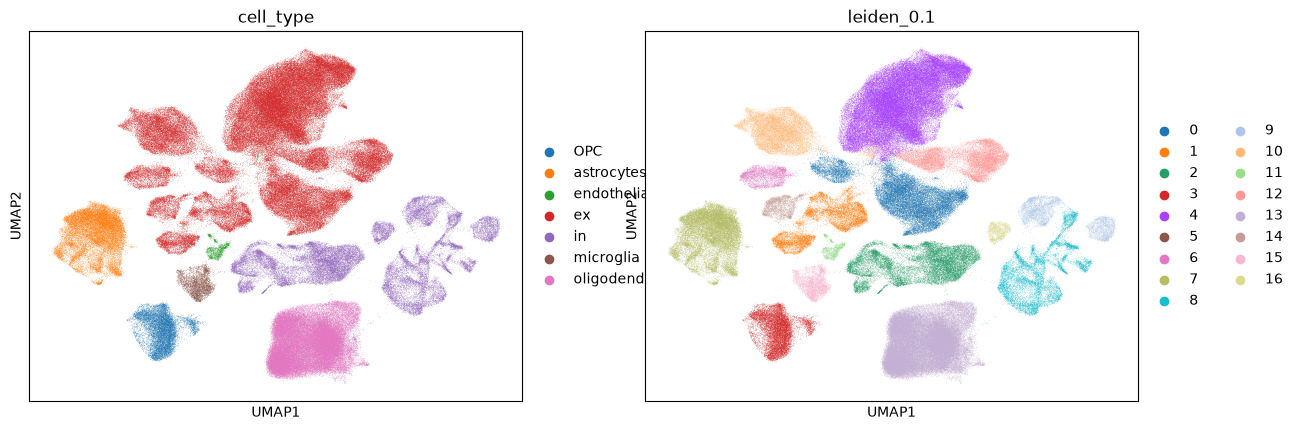

In [54]:
sc.pl.umap(adata, color=["cell_type", "leiden_0.1"])

In [55]:
q = adata.obs[["total_counts", "n_genes_by_counts"]].quantile(0.9)
drop = ((adata.obs.total_counts >= q.total_counts) |
        (adata.obs.n_genes_by_counts >= q.n_genes_by_counts))
per = drop.groupby(adata.obs.sample_id).mean().sort_values()
print(per.round(3).to_string())

sample_id
PFCTX041    0.012
PFCTX046    0.013
PFCTX025    0.019
PFCTX039    0.026
PFCTX026    0.032
PFCTX020    0.034
PFCTX045    0.042
PFCTX040    0.046
PFCTX023    0.059
PFCTX033    0.062
PFCTX027    0.062
PFCTX037    0.065
PFCTX034    0.070
PFCTX032    0.072
PFCTX002    0.082
PFCTX008    0.087
PFCTX011    0.087
PFCTX018    0.094
PFCTX012    0.097
PFCTX030    0.104
PFCTX021    0.105
PFCTX014    0.110
PFCTX029    0.115
PFCTX031    0.120
PFCTX022    0.124
PFCTX019    0.126
PFCTX009    0.127
PFCTX003    0.130
PFCTX044    0.132
PFCTX024    0.135
PFCTX017    0.137
PFCTX001    0.138
PFCTX028    0.160
PFCTX042    0.164
PFCTX010    0.166
PFCTX043    0.172
PFCTX015    0.177
PFCTX013    0.182
PFCTX035    0.198
PFCTX038    0.210
PFCTX016    0.328
PFCTX004    0.442
PFCTX036    0.457
PFCTX007    0.467
PFCTX006    0.572
PFCTX005    0.579


/tmp/ipykernel_4098156/1902443994.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per = drop.groupby(adata.obs.sample_id).mean().sort_values()


## Our pre-procesing differs from Nido et. al

Our QC plot reveals that applying the fixed qunatile based filter from the paper:
```
keep.cb <- (nCount_RNA < quantile(nCount_RNA, 0.9)) &
    (nFeature_RNA < quantile(nFeature_RNA, 0.9)) &
    (!integrated_snn_res.0.1 %in% c(20,21)) &
    colnames(sc.integrated) %in% singlets &
    integrated_snn_res.0.1 != 17
```
removes disproportionally more cells from differenr donors. We already established that dome donors have a higher sequencing depth. We found a negative correlation between the number of cells and the total counts per donor: the less cells (material) went into the lane, the more counts the donor obtained. This makes sense because each sequencing run gets sequenced to a fixed total number of transcripts. WIth less cells to share this pool, the detected transcripts and thus the sequencing depth of each cell rises. 

## Next

- continue in chat *Single-cell RNA filtering pipeline output*

In [13]:
import sys
print(sys.executable)
import igraph; print(igraph.__version__, igraph.__file__)

/local/fkriegel/miniconda3/envs/scvi_env/bin/python
1.0.0 /local/fkriegel/miniconda3/envs/scvi_env/lib/python3.11/site-packages/igraph/__init__.py


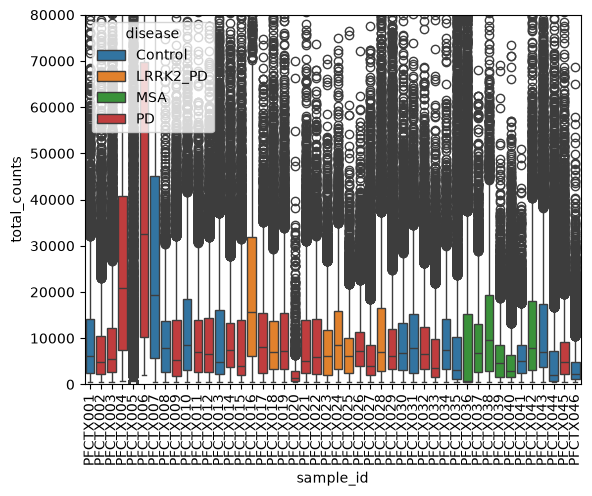

In [ ]:
sns.boxplot(
    data=adata.obs,
    x="sample_id",
    y="total_counts",
    hue='disease'
)
plt.ylim(0, 80000)
plt.xticks(rotation=90);

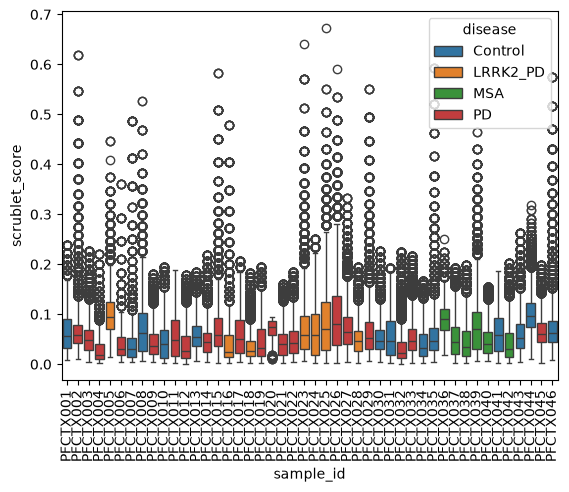

In [ ]:
sns.boxplot(
    data=adata.obs,
    x="sample_id",
    y="scrublet_score",
    hue='disease'
)
plt.xticks(rotation=90);

In [ ]:
scipy.stats.pearsonr(adata.obs.total_counts, adata.obs.scrublet_score)

PearsonRResult(statistic=np.float64(0.2247483656582154), pvalue=np.float64(0.0))

In [ ]:
adata.obs.scrublet_score

AAACCCACACTTCATT-1-PFCTX001_filtered    0.054326
AGAAATGGTTGCTCGG-1-PFCTX001_filtered    0.187595
TTCACGCCATCATGAC-1-PFCTX001_filtered    0.090495
CTCACTGCAGGCTACC-1-PFCTX001_filtered    0.113208
TGCAGATTCTTCGGAA-1-PFCTX001_filtered    0.113208
                                          ...   
AAGACAAGTTCGGTAT-1-PFCTX046_filtered    0.058084
GTGTGATAGTGCAGCA-1-PFCTX046_filtered    0.021732
ACTCCCAGTTGAGTCT-1-PFCTX046_filtered    0.115417
GTCGTAAAGGATACAT-1-PFCTX046_filtered    0.032709
TGTAGACAGCCTGTGC-1-PFCTX046_filtered    0.029905
Name: scrublet_score, Length: 433062, dtype: float64

In [ ]:
len(adata.obs.sample_id.value_counts())

46

In [ ]:
# take filtering from the paper
mask = (
    (adata.obs["n_genes_by_counts"] < 500)
    & (adata.obs["total_counts"] < 1000)
)
adata = adata[~mask].copy()

In [ ]:
adata

AnnData object with n_obs × n_vars = 410500 × 36620
    obs: 'dataset_key', 'dataset_id', 'tissue', 'donor_id', 'sample_id', 'sex', 'disease', 'organ_canonical', 'source_file', 'gen_sample_id', 'gen_cohort', 'gen_biobank_id', 'gen_bulk_rna_id', 'gen_age_death', 'gen_pmi_hours', 'gen_braak_lb', 'gen_rin', 'gen_lrrk2_variant', 'source_batch_key', 'disease_term_canonical', 'disease_ontology_term_id_canonical', 'disease_status', 'disease_category_canonical', 'disease_category_id', 'disease_term_id', 'disease_subtype_canonical', 'disease_subtype_id', 'disease_subtype_source', 'disease_comorbidity', 'genotype_panel', 'genotype_method', 'genotype_source', 'pd_variant_genes', 'pd_variant_alleles', 'pd_variant_zygosity', 'pd_variant_inheritance', 'pd_variant_count', 'genetic_etiology', 'genetic_etiology_gene', 'genetic_etiology_mode', 'hoehn_yahr_stage', 'hoehn_yahr_stage_group', 'hoehn_yahr_stage_source', 'sex_canonical', 'tissue_raw', 'tissue_original', 'tissue_canonical', 'tissue_allen_struc

In [ ]:
a = adata.X[0].toarray()
print(a[a>0])

[ 1  1 11 ...  1  2  8]


/home/florian/miniconda3/envs/moma_pd/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/home/florian/miniconda3/envs/moma_pd/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


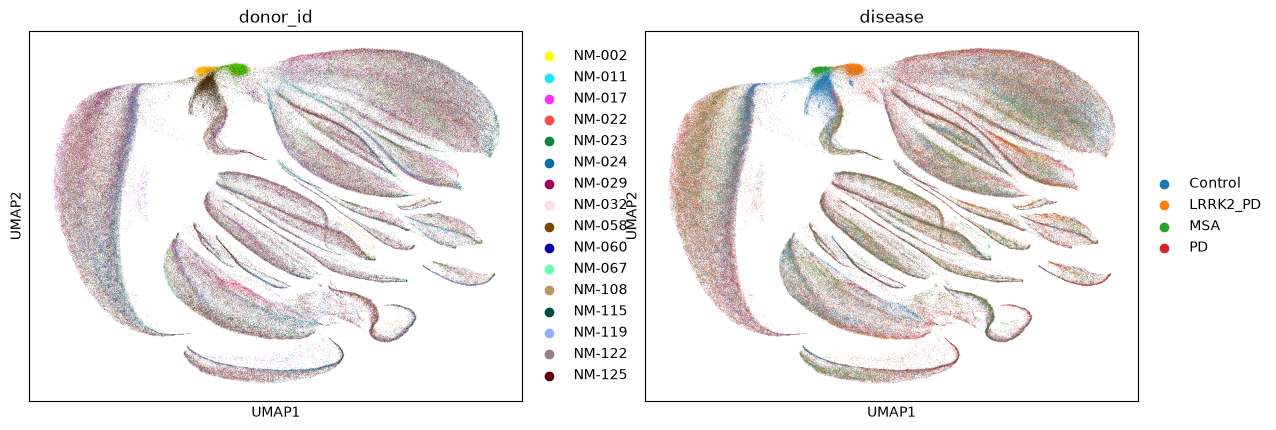

In [ ]:
# adata
adata = adata.copy()

# clear embeddings inherited from the multi-celltype parent
for k in ["X_pca", "X_umap"]:
    adata.obsm.pop(k, None)
adata.uns.pop("neighbors", None)
adata.obsp.pop("distances", None)
adata.obsp.pop("connectivities", None)

# re-select HVGs on the monocyte subset only
if "counts" in adata.layers:
    sc.pp.highly_variable_genes(
        adata, n_top_genes=3000, flavor="seurat_v3", layer="counts"
    )
else:
    sc.pp.highly_variable_genes(adata, n_top_genes=3000, flavor="seurat_v3")

adata.raw = adata
adata_hvg = adata[:, adata.var.highly_variable].copy()

sc.pp.scale(adata_hvg, max_value=10)
sc.tl.pca(adata_hvg, n_comps=50, svd_solver="arpack")
sc.pp.neighbors(adata_hvg, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata_hvg, min_dist=0.3)

# carry the embedding back onto the full gene set
adata.obsm["X_pca"] = adata_hvg.obsm["X_pca"]
adata.obsm["X_umap"] = adata_hvg.obsm["X_umap"]

sc.pl.umap(adata, color=["donor_id", "disease"], ncols=2)

In [ ]:
adata.obs.columns

Index(['dataset_key', 'dataset_id', 'tissue', 'donor_id', 'sample_id', 'sex',
       'disease', 'organ_canonical', 'source_file', 'gen_sample_id',
       'gen_cohort', 'gen_biobank_id', 'gen_bulk_rna_id', 'gen_age_death',
       'gen_pmi_hours', 'gen_braak_lb', 'gen_rin', 'gen_lrrk2_variant',
       'source_batch_key', 'disease_term_canonical',
       'disease_ontology_term_id_canonical', 'disease_status',
       'disease_category_canonical', 'disease_category_id', 'disease_term_id',
       'disease_subtype_canonical', 'disease_subtype_id',
       'disease_subtype_source', 'disease_comorbidity', 'genotype_panel',
       'genotype_method', 'genotype_source', 'pd_variant_genes',
       'pd_variant_alleles', 'pd_variant_zygosity', 'pd_variant_inheritance',
       'pd_variant_count', 'genetic_etiology', 'genetic_etiology_gene',
       'genetic_etiology_mode', 'hoehn_yahr_stage', 'hoehn_yahr_stage_group',
       'hoehn_yahr_stage_source', 'sex_canonical', 'tissue_raw',
       'tissue_origin

In [ ]:
adata.obs.called_doublet_scrublet.value_counts()

called_doublet_scrublet
False    433062
Name: count, dtype: int64

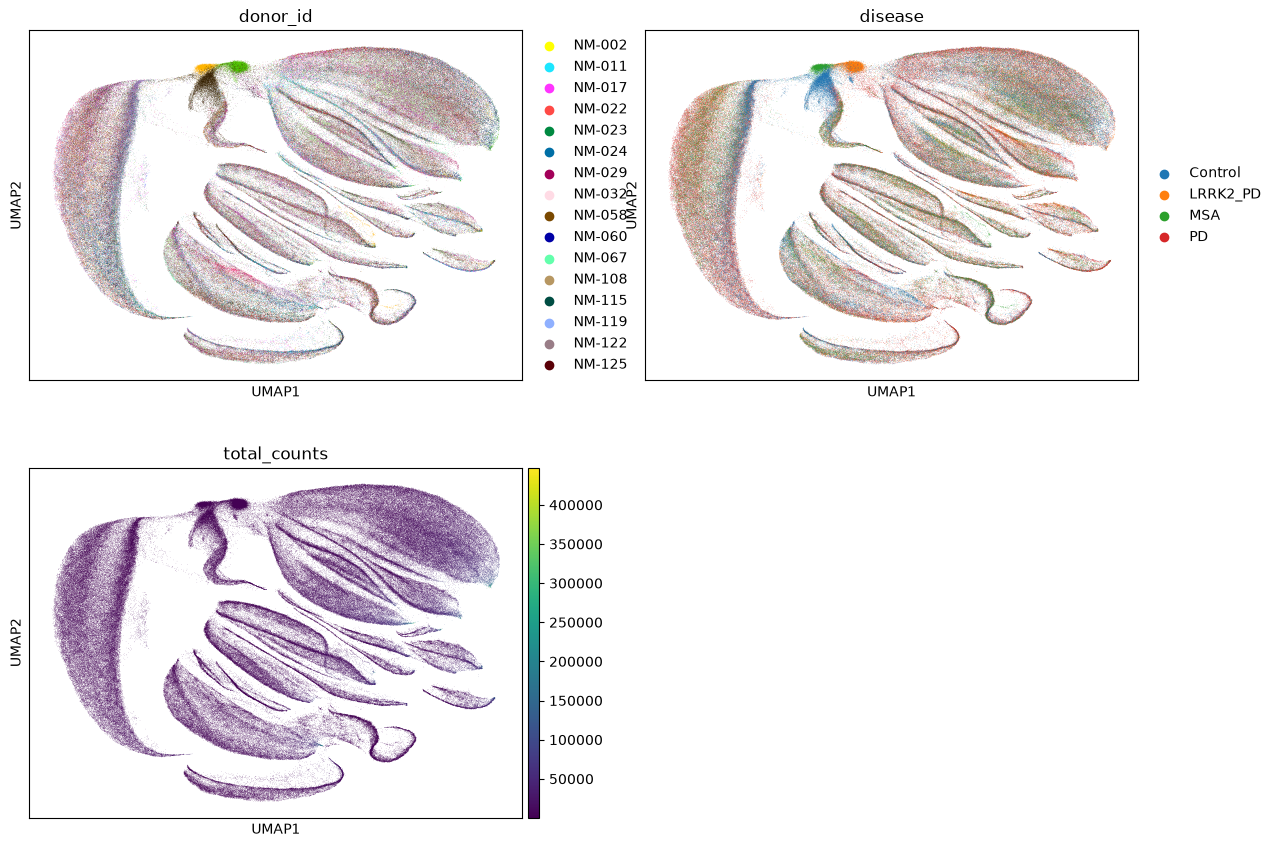

In [ ]:
sc.pl.umap(adata, color=["donor_id", "disease", "total_counts", "scrublet_score"], ncols=2)

(array([2.0509e+05, 8.3235e+04, 4.9912e+04, 3.0504e+04, 2.0001e+04,
        1.3086e+04, 8.7050e+03, 5.7520e+03, 4.1580e+03, 2.8940e+03,
        2.1080e+03, 1.4490e+03, 1.2130e+03, 9.0700e+02, 7.0600e+02,
        5.7700e+02, 4.7400e+02, 3.5000e+02, 2.7900e+02, 2.1900e+02,
        1.9100e+02, 1.6000e+02, 1.4400e+02, 1.1500e+02, 1.0700e+02,
        7.7000e+01, 8.6000e+01, 5.9000e+01, 6.3000e+01, 6.0000e+01,
        4.1000e+01, 3.0000e+01, 2.0000e+01, 2.6000e+01, 1.9000e+01,
        2.9000e+01, 2.5000e+01, 2.3000e+01, 2.2000e+01, 1.4000e+01,
        1.4000e+01, 1.5000e+01, 1.0000e+01, 5.0000e+00, 9.0000e+00,
        7.0000e+00, 7.0000e+00, 7.0000e+00, 8.0000e+00, 4.0000e+00,
        4.0000e+00, 1.0000e+00, 6.0000e+00, 3.0000e+00, 3.0000e+00,
        2.0000e+00, 4.0000e+00, 0.0000e+00, 3.0000e+00, 3.0000e+00,
        2.0000e+00, 0.0000e+00, 2.0000e+00, 3.0000e+00, 1.0000e+00,
        0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00,
        1.0000e+00, 0.0000e+00, 0.0000e+00, 0.00

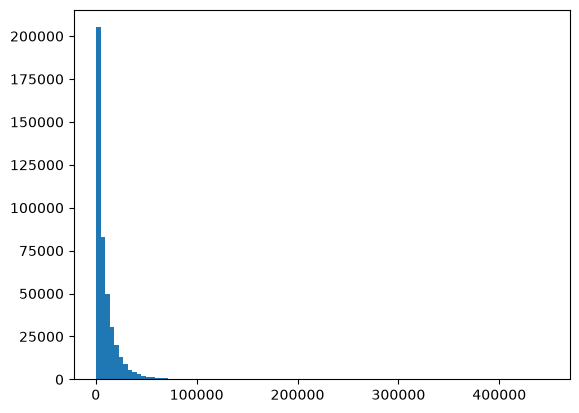

In [ ]:
plt.hist(adata.obs.total_counts, bins=100)

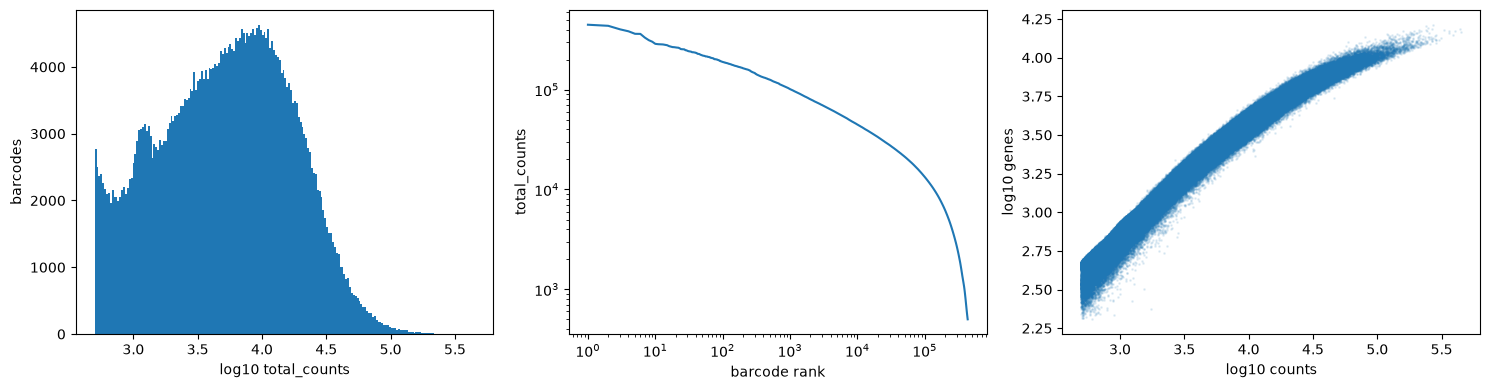

          count  median       max
donor_id                         
NM-571    20185  1981.0  119594.0
NM-186    16280  2800.0   84855.0
NM-130    15361  6124.0   76558.0
NM-758    14352  7228.5   72089.0
NM-017    14263  3992.0  115442.0
NM-759    14198  5066.5   50987.0
NM-267    13879  3439.0   80014.0
NM-182    13825  4563.0   96027.0
NM-138    12169  6644.0  128171.0
NM-122    11341  6039.0   70414.0
NM-125    11212  7021.5  130595.0
NM-144    11034  5185.0   89116.0
NM-627    10993  6745.0   99667.0
NM-590    10637  7841.0   84877.0
NM-274    10623  7519.0  242072.0
NM-148    10534  6579.5   94962.0
NM-174    10319  7894.0  117078.0
NM-024    10179  5073.0   87639.0
NM-229    10069  4932.0  143501.0
NM-131     9924  1194.5  447495.0


In [ ]:
import numpy as np, matplotlib.pyplot as plt

tc = np.asarray(adata.obs["total_counts"])
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].hist(np.log10(tc), bins=200)
ax[0].set_xlabel("log10 total_counts"); ax[0].set_ylabel("barcodes")

r = np.argsort(np.argsort(-tc)) + 1
o = np.argsort(-tc)
ax[1].loglog(r[o], tc[o]); ax[1].set_xlabel("barcode rank"); ax[1].set_ylabel("total_counts")

ax[2].scatter(np.log10(tc), np.log10(adata.obs["n_genes_by_counts"] + 1), s=1, alpha=.1)
ax[2].set_xlabel("log10 counts"); ax[2].set_ylabel("log10 genes")
plt.tight_layout(); plt.show()

print(adata.obs.groupby("donor_id", observed=True)["total_counts"]
      .agg(["count", "median", "max"]).sort_values("count", ascending=False).head(20))

In [ ]:
import numpy as np, pandas as pd
from scipy.stats import median_abs_deviation as mad

def mad_outlier(x, nmads=3, log=True, side="both"):
    """Boolean mask of outliers, computed on log1p scale by default."""
    v = np.log1p(x) if log else np.asarray(x, float)
    m, s = np.median(v), mad(v, scale="normal")
    lo, hi = m - nmads * s, m + nmads * s
    if side == "high":  return v > hi
    if side == "low":   return v < lo
    return (v < lo) | (v > hi)

DONOR = "donor_id"          # or sample_id / library
obs = adata.obs

flags = pd.DataFrame(index=obs.index)
for d, idx in obs.groupby(DONOR, observed=True).groups.items():
    sub = obs.loc[idx]
    flags.loc[idx, "out_counts"] = mad_outlier(sub["total_counts"], 3)
    flags.loc[idx, "out_genes"]  = mad_outlier(sub["n_genes_by_counts"], 3)
    flags.loc[idx, "out_mt"]     = mad_outlier(sub["pct_counts_mt"], 3,
                                               log=False, side="high")

flags = flags.astype(bool)
# hard floors as a safety net against libraries that are bad end-to-end
flags["out_hard"] = (obs["n_genes_by_counts"] < 200) | (obs["total_counts"] < 500)
flags["drop"] = flags.any(axis=1)

adata.obs = adata.obs.join(flags)
print(flags.sum(), "\n")
print(f"total dropped: {flags['drop'].sum()} / {len(flags)} ({100*flags['drop'].mean():.1f}%)")

out_counts     4606
out_genes     10213
out_mt        66171
out_hard          0
drop          74487
dtype: int64 

total dropped: 74487 / 433062 (17.2%)


In [ ]:
# per-donor threshold table + drop rates
rows = []
for d, idx in obs.groupby(DONOR, observed=True).groups.items():
    sub, f = obs.loc[idx], flags.loc[idx]
    lv = np.log1p(sub["total_counts"])
    rows.append({
        DONOR: d, "n": len(sub),
        "count_lo": np.expm1(np.median(lv) - 3*mad(lv, scale="normal")).round(0),
        "count_hi": np.expm1(np.median(lv) + 3*mad(lv, scale="normal")).round(0),
        "mt_hi": (np.median(sub["pct_counts_mt"])
                  + 3*mad(sub["pct_counts_mt"], scale="normal")).round(2),
        "pct_dropped": (100 * f["drop"].mean()).round(1),
    })
thr = pd.DataFrame(rows).sort_values("pct_dropped", ascending=False)
print(thr.to_string(index=False))

donor_id     n  count_lo  count_hi  mt_hi  pct_dropped
  NM-029  7443      88.0  184686.0   0.00         47.3
  NM-186 16280     162.0   48250.0   0.09         37.6
  NM-582  6284      91.0    7621.0   2.08         36.7
  NM-131  9924     699.0    2040.0   0.53         25.7
  NM-022  8008     447.0  125285.0   1.43         23.6
  NM-758 14352     756.0   69010.0   0.87         23.2
  NM-067  7396     347.0  181238.0   0.65         22.5
  NM-600  8949     105.0   46848.0   2.85         22.4
  NM-122 11341     141.0  256382.0   0.37         21.5
  NM-130 15361     402.0   93162.0   0.92         21.2
  NM-224  8148     245.0  203334.0   0.11         19.9
  NM-144 11034      57.0  462524.0   0.41         18.5
  NM-182 13825     154.0  134821.0   0.55         18.4
  NM-119  8074     102.0  334649.0   0.39         18.0
  NM-267 13879      73.0  159955.0   0.43         17.4
  NM-002  7515     182.0  170197.0   2.37         17.3
  NM-145  9527     364.0  104768.0   1.43         16.8
  NM-226  

In [ ]:
import numpy as np, pandas as pd
from scipy.stats import median_abs_deviation as mad

print("MT genes present:", adata.var_names.str.startswith("MT-").sum())
mt = adata.obs["pct_counts_mt"]
print(f"global: frac==0 {(mt==0).mean():.3f} | median {mt.median():.3f} | "
      f"q95 {mt.quantile(.95):.2f} | max {mt.max():.2f}")

g = adata.obs.groupby("donor_id", observed=True)
diag = pd.DataFrame({
    "n": g.size(),
    "mt_frac_zero": g["pct_counts_mt"].apply(lambda x: (x == 0).mean()).round(3),
    "mt_med": g["pct_counts_mt"].median().round(3),
    "mt_mad": g["pct_counts_mt"].apply(lambda x: mad(x, scale="normal")).round(3),
    "mt_q99": g["pct_counts_mt"].quantile(.99).round(2),
    "genes_med": g["n_genes_by_counts"].median(),
})
print(diag.sort_values("mt_frac_zero", ascending=False).head(15).to_string())

MT genes present: 13
global: frac==0 0.160 | median 0.196 | q95 3.46 | max 20.00
              n  mt_frac_zero  mt_med  mt_mad  mt_q99  genes_med
donor_id                                                        
NM-029     7443         0.527   0.000   0.000    2.93     2112.0
NM-186    16280         0.492   0.016   0.023   14.68     1613.0
NM-224     8148         0.408   0.020   0.029    1.08     2776.0
NM-122    11341         0.348   0.069   0.102    8.65     2961.0
NM-032     7326         0.344   0.030   0.045    2.30     3576.5
NM-267    13879         0.339   0.079   0.117    4.05     1895.0
NM-119     8074         0.325   0.073   0.107    7.60     2923.5
NM-144    11034         0.325   0.075   0.112   11.42     2570.5
NM-226     6835         0.284   0.047   0.070   10.66     2976.0
NM-182    13825         0.269   0.100   0.149    9.70     2555.0
NM-759    14198         0.216   0.059   0.088    2.30     2662.5
NM-024    10179         0.190   0.116   0.160    5.54     2471.0
NM-067   

In [ ]:
MT_CAP, NMADS = 5.0, 5     # absolute cap; wider interval for bimodal data

flags = pd.DataFrame(index=adata.obs.index)
for d, idx in adata.obs.groupby("donor_id", observed=True).groups.items():
    sub = adata.obs.loc[idx]
    lv = np.log1p(sub["n_genes_by_counts"])
    m, s = np.median(lv), mad(lv, scale="normal")
    flags.loc[idx, "out_genes_low"] = lv < (m - NMADS * s)      # one-sided only
    # per-donor mito bound, but floored so a degenerate MAD can't drive it to 0
    mm = sub["pct_counts_mt"]
    thr = max(np.median(mm) + 3 * mad(mm, scale="normal"), MT_CAP)
    flags.loc[idx, "out_mt"] = mm > thr

flags = flags.astype(bool)
flags["drop"] = flags.any(axis=1)
print(flags.sum(), "\n")

# decompose: which flag drives each donor's loss
dec = flags.join(adata.obs["donor_id"]).groupby("donor_id", observed=True).mean().mul(100).round(1)
print(dec.sort_values("drop", ascending=False).head(12).to_string())

out_genes_low      193
out_mt           13958
drop             14150
dtype: int64 

          out_genes_low  out_mt  drop
donor_id                             
NM-600              0.0    14.1  14.1
NM-562              0.0    13.5  13.5
NM-023              0.0     9.0   9.0
NM-011              0.0     8.9   8.9
NM-002              0.0     7.5   7.5
NM-017              0.0     6.7   6.7
NM-128              0.0     6.0   6.0
NM-571              0.0     5.9   5.9
NM-067              0.0     5.9   5.9
NM-022              0.0     5.5   5.5
NM-547              0.0     4.5   4.5
NM-186              0.0     4.4   4.4


In [ ]:
adata.obs.columns

Index(['dataset_key', 'dataset_id', 'tissue', 'donor_id', 'sample_id', 'sex',
       'disease', 'organ_canonical', 'source_file', 'gen_sample_id',
       'gen_cohort', 'gen_biobank_id', 'gen_bulk_rna_id', 'gen_age_death',
       'gen_pmi_hours', 'gen_braak_lb', 'gen_rin', 'gen_lrrk2_variant',
       'source_batch_key', 'disease_term_canonical',
       'disease_ontology_term_id_canonical', 'disease_status',
       'disease_category_canonical', 'disease_category_id', 'disease_term_id',
       'disease_subtype_canonical', 'disease_subtype_id',
       'disease_subtype_source', 'disease_comorbidity', 'genotype_panel',
       'genotype_method', 'genotype_source', 'pd_variant_genes',
       'pd_variant_alleles', 'pd_variant_zygosity', 'pd_variant_inheritance',
       'pd_variant_count', 'genetic_etiology', 'genetic_etiology_gene',
       'genetic_etiology_mode', 'hoehn_yahr_stage', 'hoehn_yahr_stage_group',
       'hoehn_yahr_stage_source', 'sex_canonical', 'tissue_raw',
       'tissue_origin